In [22]:
import numpy as np
%load_ext autoreload
%autoreload 2

import materialdatabase as mdb
from hybridmag.utils import comsol_interface as comsol

from utils import material_processing as materials
from utils import infinite_cylinder as ic
from utils.physics import *
from utils.maths import *
from meta import paths

from matplotlib import pyplot as plt


path2simulations = paths.simulation_data
path2plots = paths.grafics

# -------------------------
# Helpfully definitions
# -------------------------
cm = 1 / 2.54

# -------------------------
# Matplotlib settings
# -------------------------
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.sans-serif": ["Bitstream Vera Sans", "DejaVu Sans", "Helvetica", "Arial", "sans-serif"],
    "font.size": 10.0,
    "text.latex.preamble": r"\usepackage{upgreek}\usepackage{siunitx}",
    "mathtext.fontset": "custom",
    "mathtext.rm": "Bitstream Vera Serif",
    "mathtext.it": "Bitstream Vera Serif:italic",
    "mathtext.bf": "Bitstream Vera Serif:bold"
})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Material Definition

In [23]:
# -------------------------
# Material (linear)
# -------------------------
mu_real, mu_imag = 2124, 354
mu_lin = mu_0 * (mu_real - 1j * mu_imag)
print(f"Permeability: {np.round(abs(mu_lin) / mu_0, decimals=2)}")
print(f"mag. loss angle: {np.round(np.rad2deg(np.arctan(mu_lin.imag / mu_lin.real)), decimals=2)}")

eps_real, eps_imag = 79201, 33595
eps_lin = epsilon_0 * (eps_real - 1j * eps_imag)
print(f"Permittivity: {np.round(abs(eps_lin) / epsilon_0, decimals=2)}")
print(f"el. loss angle: {np.round(np.rad2deg(np.arctan(eps_lin.imag / eps_lin.real)), decimals=2)}")

Permeability: 2153.3
mag. loss angle: -9.46
Permittivity: 86031.52
el. loss angle: -22.99


### IC vs. 2D FEM

In [24]:
# -------------------------
# Geometry definition
# -------------------------
R = 7.5e-3  # radius

#### Linear

MRE (IC): 0.28 %
MRE (static): -56.0 %


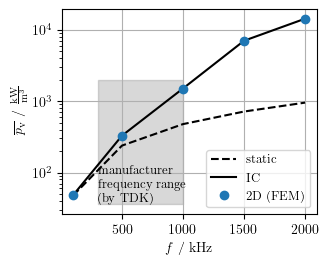

In [25]:
# -------------------------
# 2D FEM losses
# -------------------------
df_2D_FEM = comsol.read_df_from_comsol_table(
    link2file=path2simulations.joinpath("IC_model/results_linear.txt"),
    header=["f", "PF_dim", "b_mean", "p_v", "p_mag", "p_el"]
)

# -------------------------
# Loop over frequencies according to FEM results
# -------------------------
pv_IC, pv_static = [], []
for index, row in df_2D_FEM.iterrows():
    f = row["f"] * 1000
    b_mean = row["b_mean"] / 1000

    # -------------------------
    # IC model
    # -------------------------
    pv_IC.append(ic.pv_linear(R=R, f=f, b_mean=b_mean, eps=eps_lin, mu=mu_lin))

    # -------------------------
    # Static model
    # -------------------------
    pv_static.append(ic.pv_linear(R=R, f=f, b_mean=b_mean, eps=epsilon_0, mu=mu_lin))


# -------------------------
# Plots
# -------------------------
fig, ax = plt.subplots(figsize=(8.6 * cm, 7 * cm))

ax.semilogy(df_2D_FEM["f"], np.array(pv_static) / 1000, "--", label=r"static", color="black")
ax.semilogy(df_2D_FEM["f"], np.array(pv_IC) / 1000, "-", label=r"IC", color="black")
ax.semilogy(df_2D_FEM["f"], df_2D_FEM["p_v"] / 1000, "o", label=f"2D (FEM)")

# Error metrics
rel_err_IC = (np.array(pv_IC) - df_2D_FEM["p_v"]) / df_2D_FEM["p_v"]
rel_err_static = (np.array(pv_static) - df_2D_FEM["p_v"]) / df_2D_FEM["p_v"]
print(f"MRE (IC): {np.round(np.mean(rel_err_IC)*100, decimals=2)} %")
print(f"MRE (static): {np.round(np.mean(rel_err_static)*100, decimals=2)} %")

# -------------------------
# Add shaded region (manufacturer frequency range)
# -------------------------
f_min_kHz = 300
f_max_kHz = 1000
y_min, y_max = ax.get_ylim()
y_max = 2000
ax.fill_betweenx([y_min, y_max], f_min_kHz, f_max_kHz, color='gray', alpha=0.3)
ax.text(
    f_min_kHz,
    y_min,
    "manufacturer\nfrequency range\n(by TDK)",
    ha='left', va='bottom',
    fontsize=9, color='black'
)

# -------------------------
# Final plot settings
# -------------------------
ax.set_xlabel(r"$f$ / kHz")
ax.set_ylabel(r"$\overline{p_\mathrm{v}}$ / $\frac{\mathrm{kW}}{\mathrm{m}^3}$")

ax.legend(ncols=1, loc="lower right", fontsize=9)

ax.grid()
fig.align_labels()
plt.tight_layout()

plt.savefig(path2plots.joinpath("FEM_vs_IC_losses_linear.pdf"))
plt.savefig(path2plots.joinpath("FEM_vs_IC_losses_linear.png"))
plt.show()

#### Non-linear

In [26]:
# -------------------------
# Material (nonlinear)
# -------------------------
T_c = 60

# init a material database instance
mdb_data = mdb.Data()

complex_permeability = mdb_data.get_complex_permeability(material=mdb.Material.N49,
                                                         data_source=mdb.DataSource.LEA_MTB,
                                                         pv_fit_function=mdb.FitFunction.enhancedSteinmetz)
# print(f"\nComplex permeability data: \n {complex_permeability.measurement_data} \n")
complex_permeability.fit_losses()
complex_permeability.fit_permeability_magnitude()


complex_permittivity = mdb_data.get_complex_permittivity(material=mdb.Material.N49,
                                                         data_source=mdb.DataSource.LEA_MTB)
# print(f"\nComplex permittivity data: \n {complex_permittivity.measurement_data} \n ")
complex_permittivity.fit_permittivity_magnitude()
complex_permittivity.fit_loss_angle()



c:\users\tpiepe\repositories\materialdatabase\materialdatabase\processing\utils\empirical.py:134: RuntimeWarning: invalid value encountered in log
  return np.log(enhanced_steinmetz_qT(fTb, alpha, beta, k_b, k_f, k_alpha2, c_0, c_1, c_2))


array([2.44943613e+05, 3.75991423e-01, 2.89322217e+00, 8.46446163e+07,
       1.61588339e+06, 1.19107958e+04])

MRE (IC): -0.19 %
MRE (static): -53.8 %


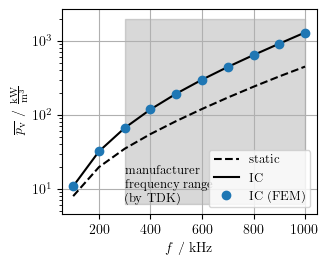

In [27]:
df_2D_FEM = comsol.read_df_from_comsol_table(
    link2file=path2simulations.joinpath("IC_model/results_non_linear.txt"),
    header=["f", "PF_dim", "b_mean", "p_v", "p_mag", "p_el"]
)
# df_2D_FEM
# -------------------------
# Loop over frequencies according to FEM results
# -------------------------
b_common = np.linspace(0, 0.2, 50)
pv_IC, pv_static = [], []
for index, row in df_2D_FEM.iterrows():
    f = row["f"] * 1000
    b_mean = row["b_mean"] / 1000

    # Permeability:
    mu_real, mu_imag = complex_permeability.fit_real_and_imaginary_part_at_f_and_T(f_op=f,
                                                                                   T_op=T_c,
                                                                                   b_vals=np.linspace(0, 0.2, 50))
    # an interpolation in terms of the magnetic field h is needed:
    mu_h = materials.mu_h_from_mu_b((mu_real - j * mu_imag) * mu_0, b_common)
    # print(mu_h(np.linspace(0, 30, 10)))

    # Permittivity:
    eps_real, eps_imag = complex_permittivity.fit_real_and_imaginary_part_at_f_and_T(f=f, T=T_c)
    eps = epsilon_0 * (eps_real - complex(0, 1) * eps_imag)
    # print(eps)


    # -------------------------
    # IC model
    # -------------------------
    pv_IC.append(ic.pv_non_linear(R=R, f=f, b_mean=b_mean, eps=eps, mu_of_h=mu_h))

    # -------------------------
    # Static model
    # -------------------------
    pv_static.append(ic.pv_non_linear(R=R, f=f, b_mean=b_mean, eps=epsilon_0, mu_of_h=mu_h))

# -------------------------
# Plots
# -------------------------
fig, ax = plt.subplots(figsize=(8.6 * cm, 7 * cm))

ax.semilogy(df_2D_FEM["f"], np.array(pv_static) / 1000, "--", label=r"static", color="black")
ax.semilogy(df_2D_FEM["f"], np.array(pv_IC) / 1000, "-", label=r"IC", color="black")
ax.semilogy(df_2D_FEM["f"], df_2D_FEM["p_v"] / 1000, "o", label=f"IC (FEM)")

# Error metrics
rel_err_IC = (np.array(pv_IC) - df_2D_FEM["p_v"]) / df_2D_FEM["p_v"]
rel_err_static = (np.array(pv_static) - df_2D_FEM["p_v"]) / df_2D_FEM["p_v"]
print(f"MRE (IC): {np.round(np.mean(rel_err_IC)*100, decimals=2)} %")
print(f"MRE (static): {np.round(np.mean(rel_err_static)*100, decimals=2)} %")


# -------------------------
# Add shaded region (manufacturer frequency range)
# -------------------------
f_min_kHz = 300
f_max_kHz = 1000
y_min, y_max = ax.get_ylim()
y_max = 2000
ax.fill_betweenx([y_min, y_max], f_min_kHz, f_max_kHz, color='gray', alpha=0.3)
ax.text(
    f_min_kHz,
    y_min,
    "manufacturer\nfrequency range\n(by TDK)",
    ha='left', va='bottom',
    fontsize=9, color='black'
)

# -------------------------
# Final plot settings
# -------------------------
ax.set_xlabel(r"$f$ / kHz")
ax.set_ylabel(r"$\overline{p_\mathrm{v}}$ / $\frac{\mathrm{kW}}{\mathrm{m}^3}$")

ax.legend(ncols=1, loc="lower right", fontsize=9)

ax.grid()
fig.align_labels()
plt.tight_layout()

plt.savefig(path2plots.joinpath("FEM_vs_IC_losses_linear.pdf"))
plt.savefig(path2plots.joinpath("FEM_vs_IC_losses_linear.png"))
plt.show()